In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_excel("EastWestAirlines.xlsx")
df

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN
5,(c) 2016 Galit Shmueli and Peter Bruce,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,Field Name,Data Type,Max Data Length,Raw Data or Telcom Created Field?,Description
9,ID#,NUMBER,NaN,Telcom,Unique ID


In [3]:
df.head()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN


In [4]:
df.shape

(26, 5)

In [22]:
#preprocessing
#handle missing values
df = df.select_dtypes(include=["number"])
print("Numeric columns:", df.columns.tolist())
print("Shape after keeping numeric:", df.shape)

Numeric columns: []
Shape after keeping numeric: (6, 0)


In [23]:
print("Missing values per column:\n", df.isna().sum())

Missing values per column:
 Series([], dtype: float64)


In [24]:
df = df.fillna(df.median())

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [26]:
print(df.isnull().sum())

Series([], dtype: float64)


In [27]:
df=df.dropna()

In [29]:
# Create a sample DataFrame for demonstration
data = {'col1': np.random.rand(100), 'col2': np.random.rand(100), 'col3': np.random.rand(100)}
df = pd.DataFrame(data)

print("Sample DataFrame created.")
display(df.head())

Sample DataFrame created.


,col1,col2,col3
0,0.314831,0.408976,0.670323
1,0.740381,0.296598,0.532190
2,0.881948,0.342109,0.637253
3,0.118310,0.043214,0.415846
4,0.928739,0.854440,0.774344


In [30]:
# Scale features


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

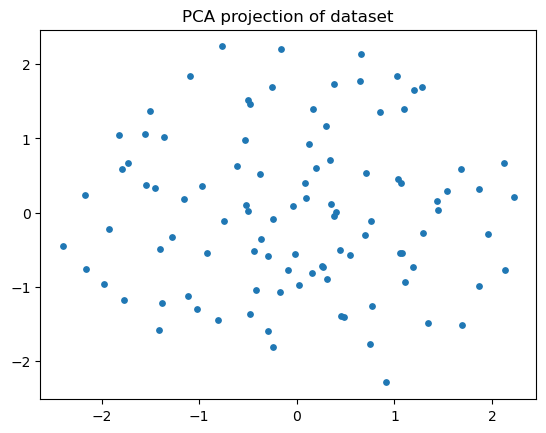

In [31]:
# PCA for visualization (2D projection only)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], s=15)
plt.title("PCA projection of dataset")
plt.show()

In [32]:
#K-Means
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia, sil_scores = [], []
K_range = range(2,9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

C:\Users\naidu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\naidu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\naidu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\naidu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

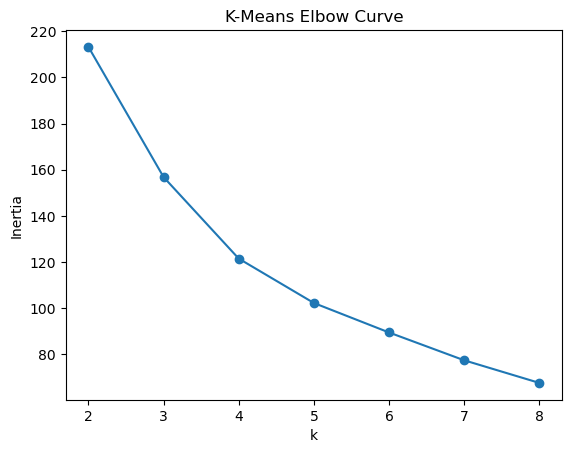

In [33]:
# Elbow curve
plt.plot(K_range, inertia, marker='o')
plt.title("K-Means Elbow Curve")
plt.xlabel("k"); plt.ylabel("Inertia")
plt.show()

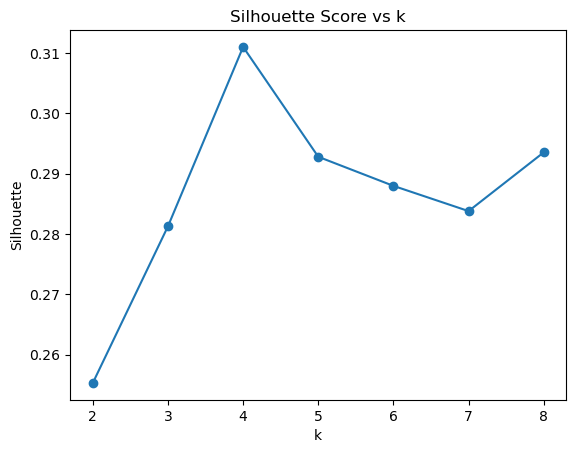

Best k = 4 with silhouette = 0.31101338063648654


C:\Users\naidu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


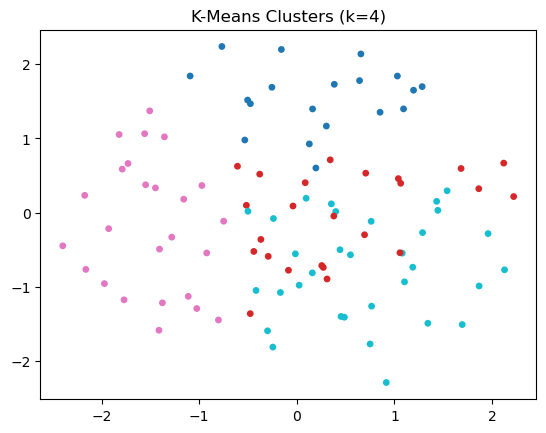

In [34]:
# Silhouette scores
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score vs k")
plt.xlabel("k"); plt.ylabel("Silhouette")
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print("Best k =", best_k, "with silhouette =", max(sil_scores))

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_km, cmap="tab10", s=15)
plt.title(f"K-Means Clusters (k={best_k})")
plt.show()

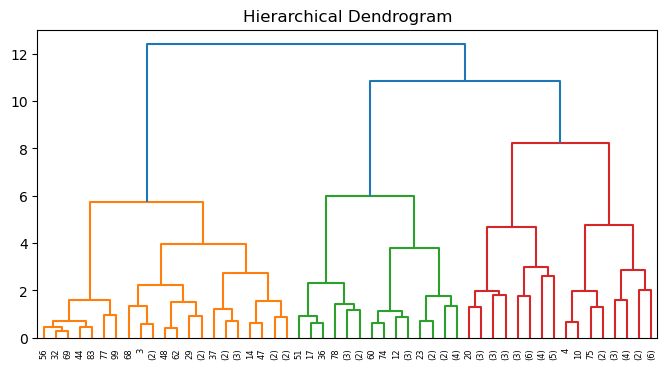

In [35]:
#Hierarchical Clustering
# Dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

link_mat = linkage(X_scaled[:200], method="ward")  # sample if too many rows
plt.figure(figsize=(8,4))
dendrogram(link_mat, truncate_mode="level", p=5)
plt.title("Hierarchical Dendrogram")
plt.show()

Agglomerative silhouette: 0.2655904386058995


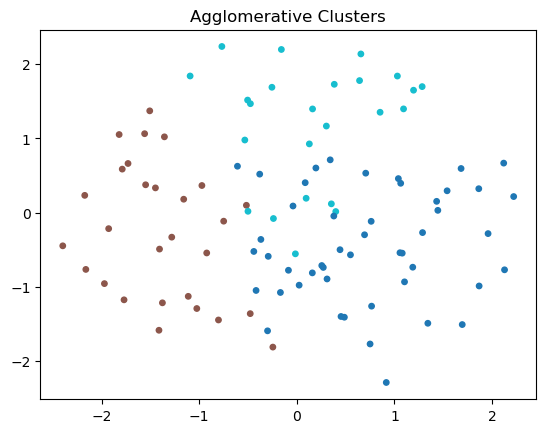

In [36]:
# Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Assuming best_k is determined from previous analysis (e.g., dendrogram or silhouette scores)
# Replace 3 with your chosen number of clusters
best_k = 3

hc = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_hc = hc.fit_predict(X_scaled)
print("Agglomerative silhouette:", silhouette_score(X_scaled, labels_hc))

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_hc, cmap="tab10", s=15)
plt.title("Agglomerative Clusters")
plt.show()

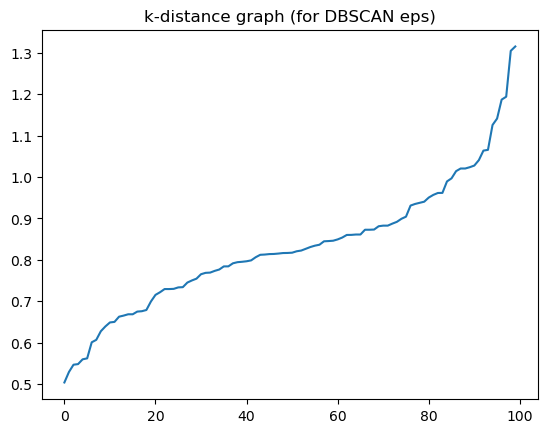

In [37]:
#DBSCAN
# Heuristic for eps: k-distance plot
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 5
nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.title("k-distance graph (for DBSCAN eps)")
plt.show()

In [38]:
# Try multiple eps and min_samples
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = [1.5, 2, 2.5]  # adjust based on plot
min_samples_list = [3,5,7]

for eps in eps_values:
    for ms in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels_db = db.fit_predict(X_scaled)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels_db)
            print(f"DBSCAN eps={eps}, min_samples={ms} -> clusters={n_clusters}, silhouette={sil:.3f}")
            plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db, cmap="tab10", s=15)
            plt.title(f"DBSCAN (eps={eps}, min_samples={ms})")
            plt.show()

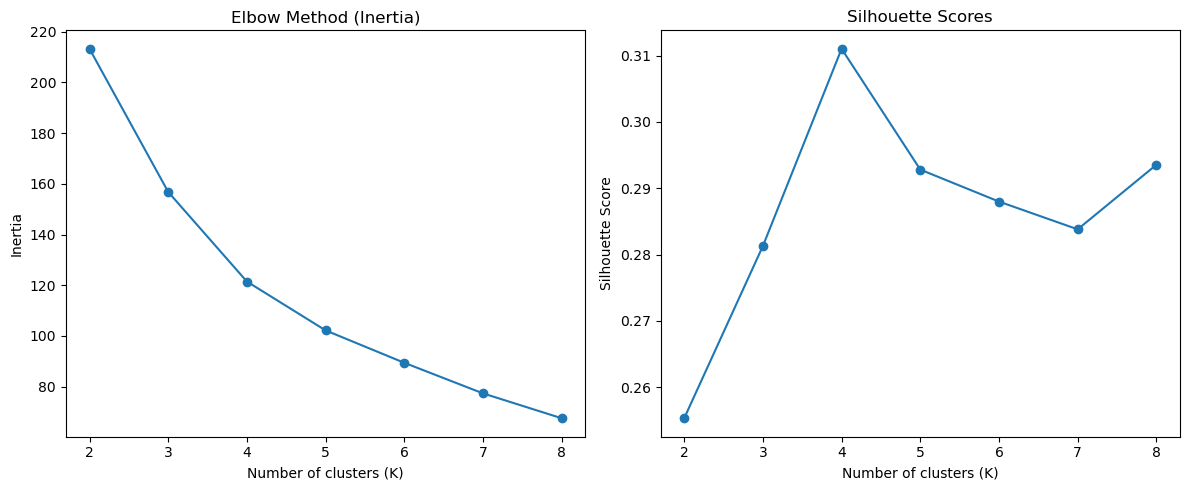

In [39]:
# Visualize inertia and silhouette scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)

plt.subplot(1, 2, 2)
plt.plot(K_range, sil_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)

plt.tight_layout()
plt.show()

In [40]:
#Attach labels back to dataframe
df_out = df.copy()
df_out["kmeans"] = labels_km
df_out["hierarchical"] = labels_hc
try:
    df_out["dbscan"] = labels_db
except:
    df_out["dbscan"] = np.nan

df_out.to_excel("EastWestAirlines_clustered.xlsx", index=False)
print("Clustered results saved to EastWestAirlines_clustered.xlsx")

Clustered results saved to EastWestAirlines_clustered.xlsx


In [41]:
# Perform KMeans clustering with a chosen number of clusters (replace 3 with your optimal K)
optimal_k = 3 # Replace with the optimal K determined from the elbow method and silhouette analysis
km = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_km = km.fit_predict(X_scaled)

print(f"KMeans clustering performed with {optimal_k} clusters.")

C:\Users\naidu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans clustering performed with 3 clusters.


### Comparison of K-Means and DBSCAN
Feature     	K-Means          	DBSCAN
Type	      Centroid-based	     Density-based
Need K value?       Yes	              No
Handles Noise?	     No	             Yes
Shape of Clusters	Spherical	     Any shape
Sensitive to Scale 	Yes              Yes